In [1]:
#Load the Dataset
import pandas as pd

In [2]:
df=pd.read_csv("adult_income.csv",na_values=['?',' ?'])

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.shape

(48842, 15)

In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  class           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [8]:
#dropping the column fnlwgt
df.drop(columns=['fnlwgt'],inplace=True)

In [9]:
#run again to verify the changes
df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [10]:
#let us analyse the statistics of the data.
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [11]:
#check whether dataset is imbalanced or not.
df['class'].value_counts()

,count
class,
<=50K,37155
>50K,11687


In [12]:
#segregate numerical type and categorical type columns.
numerical_cols=df.select_dtypes(include=['int64','float64']).columns
categorical_cols=df.select_dtypes(include=['object']).columns.drop('class')           #we have simultaneously removed the column 'class'.

In [13]:
numerical_cols

Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [14]:
categorical_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')

In [15]:
#assign separate tables for numerical and categorical data type columns.
df_numerical=df[numerical_cols]
df_categorical=df[categorical_cols]

In [16]:
df_numerical

,age,education-num,capital-gain,capital-loss,hours-per-week
0,25,7,0,0,40
1,38,9,0,0,50
2,28,12,0,0,40
3,44,10,7688,0,40
4,18,10,0,0,30
...,...,...,...,...,...
48837,27,12,0,0,38
48838,40,9,0,0,40
48839,58,9,0,0,40
48840,22,9,0,0,20


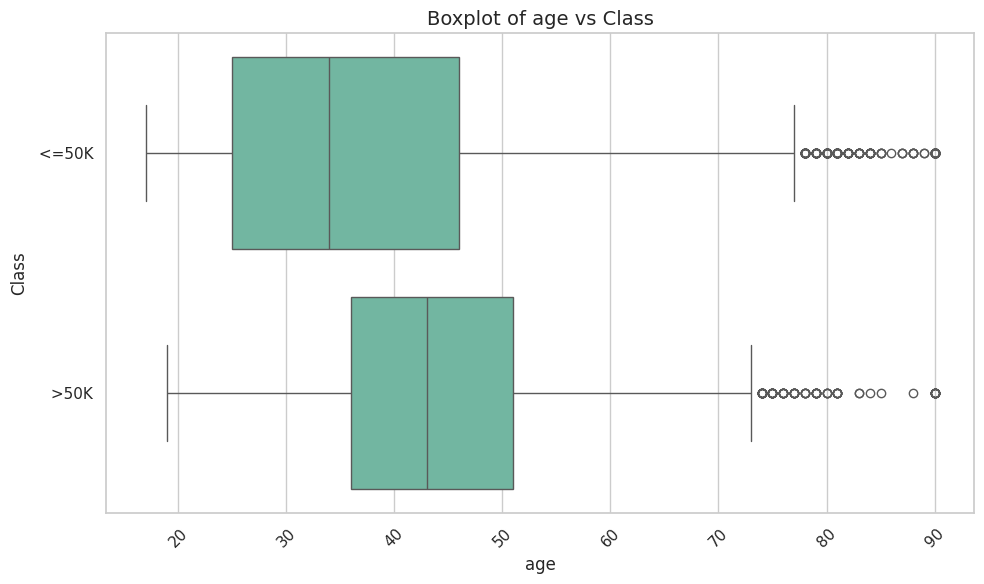

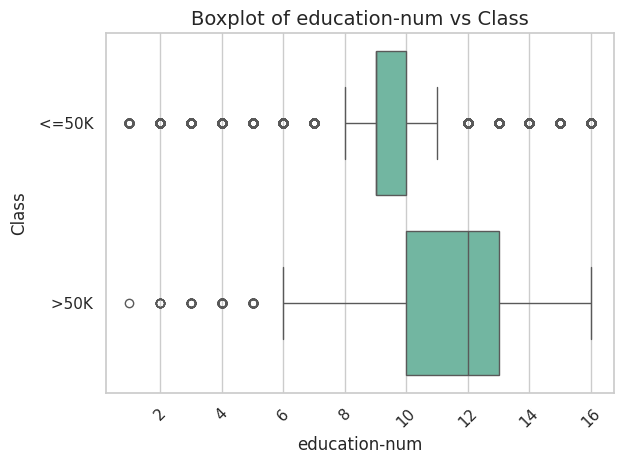

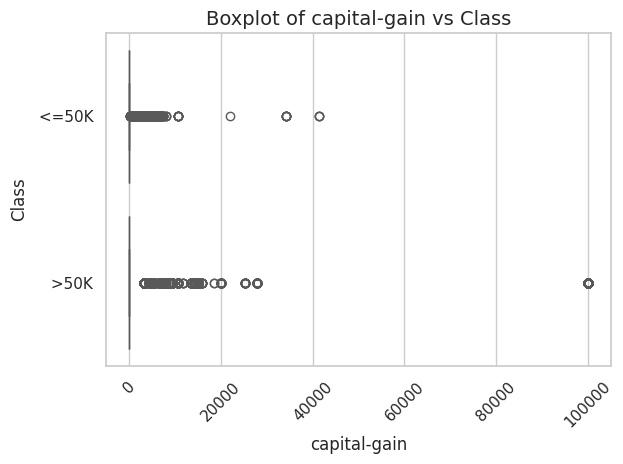

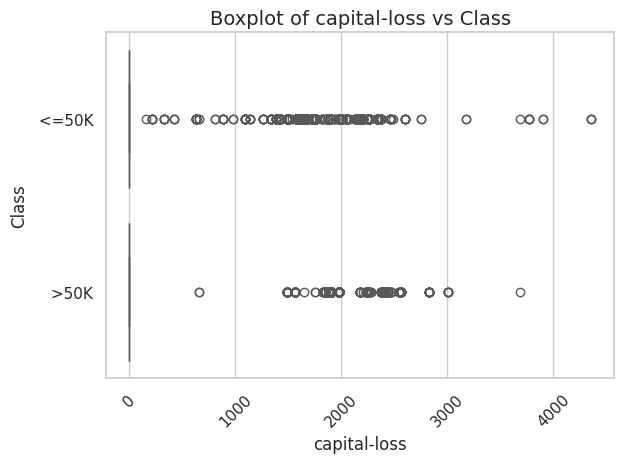

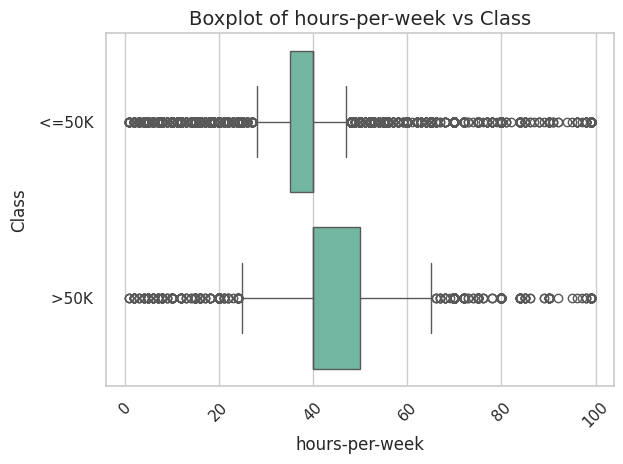

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Style Settings
sns.set_style("whitegrid")
sns.set_context("notebook")
sns.set_palette("Set2")

#Figure Size
plt.figure(figsize=(10,6))

#--Your Plot Here--
for col in numerical_cols:
  sns.boxplot(
    data=df,
    x=col,
    y="class",
  )

  plt.title(f"Boxplot of {col} vs Class",fontsize=14)
  plt.xlabel(col)
  plt.ylabel("Class")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

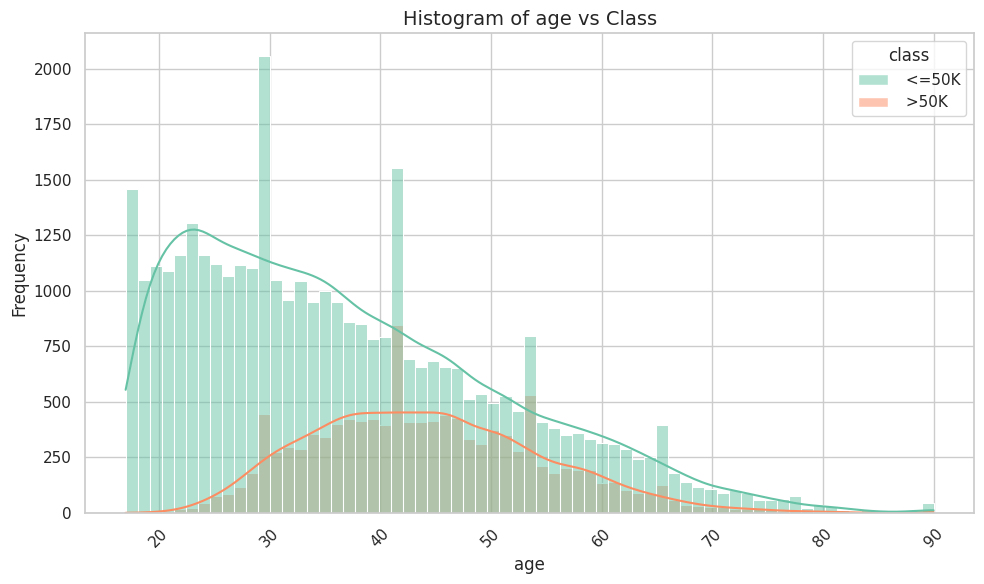

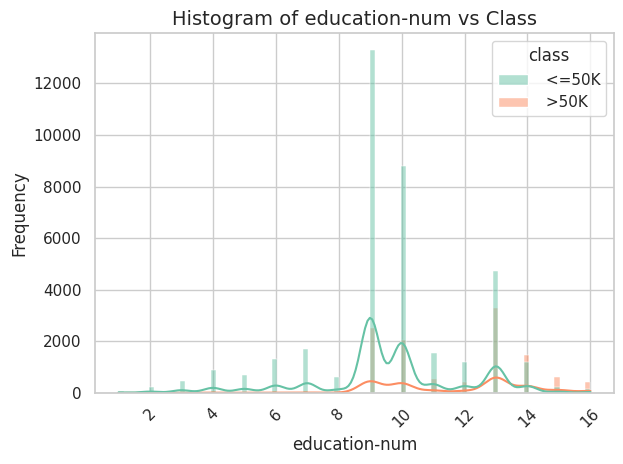

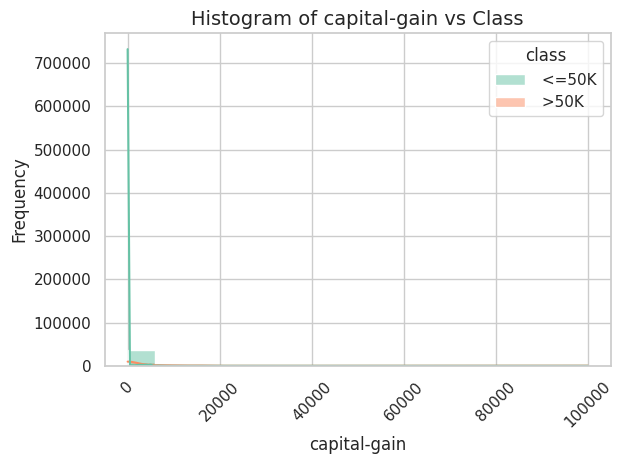

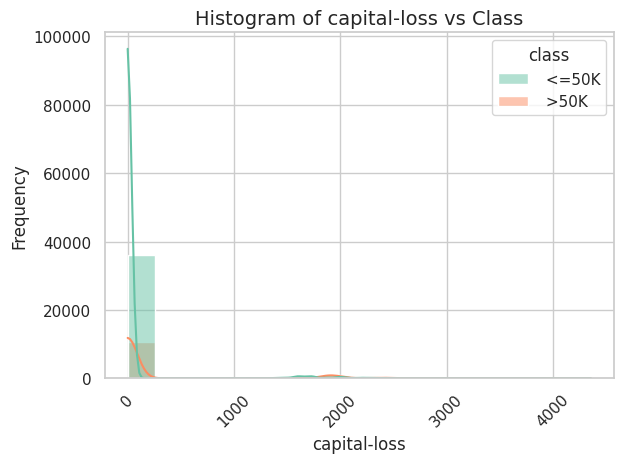

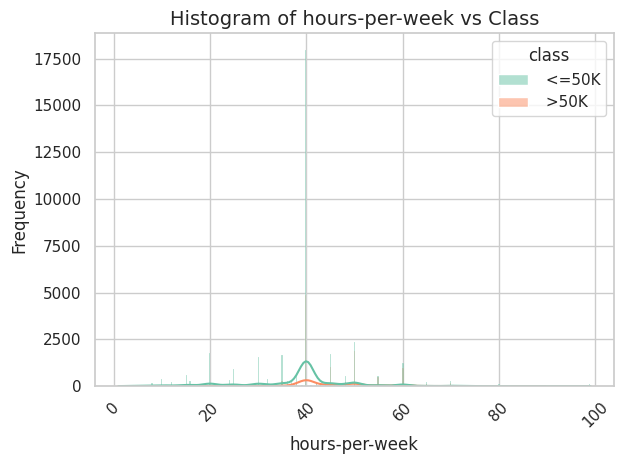

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Style Settings
sns.set_style("whitegrid")
sns.set_context("notebook")
sns.set_palette("Set2")

#Figure Size
plt.figure(figsize=(10,6))

#--Your Plot Here--
for col in numerical_cols:
  sns.histplot(
    data=df,
    kde=True,
    x=col,
    hue="class",
  )

  plt.title(f"Histogram of {col} vs Class",fontsize=14)
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

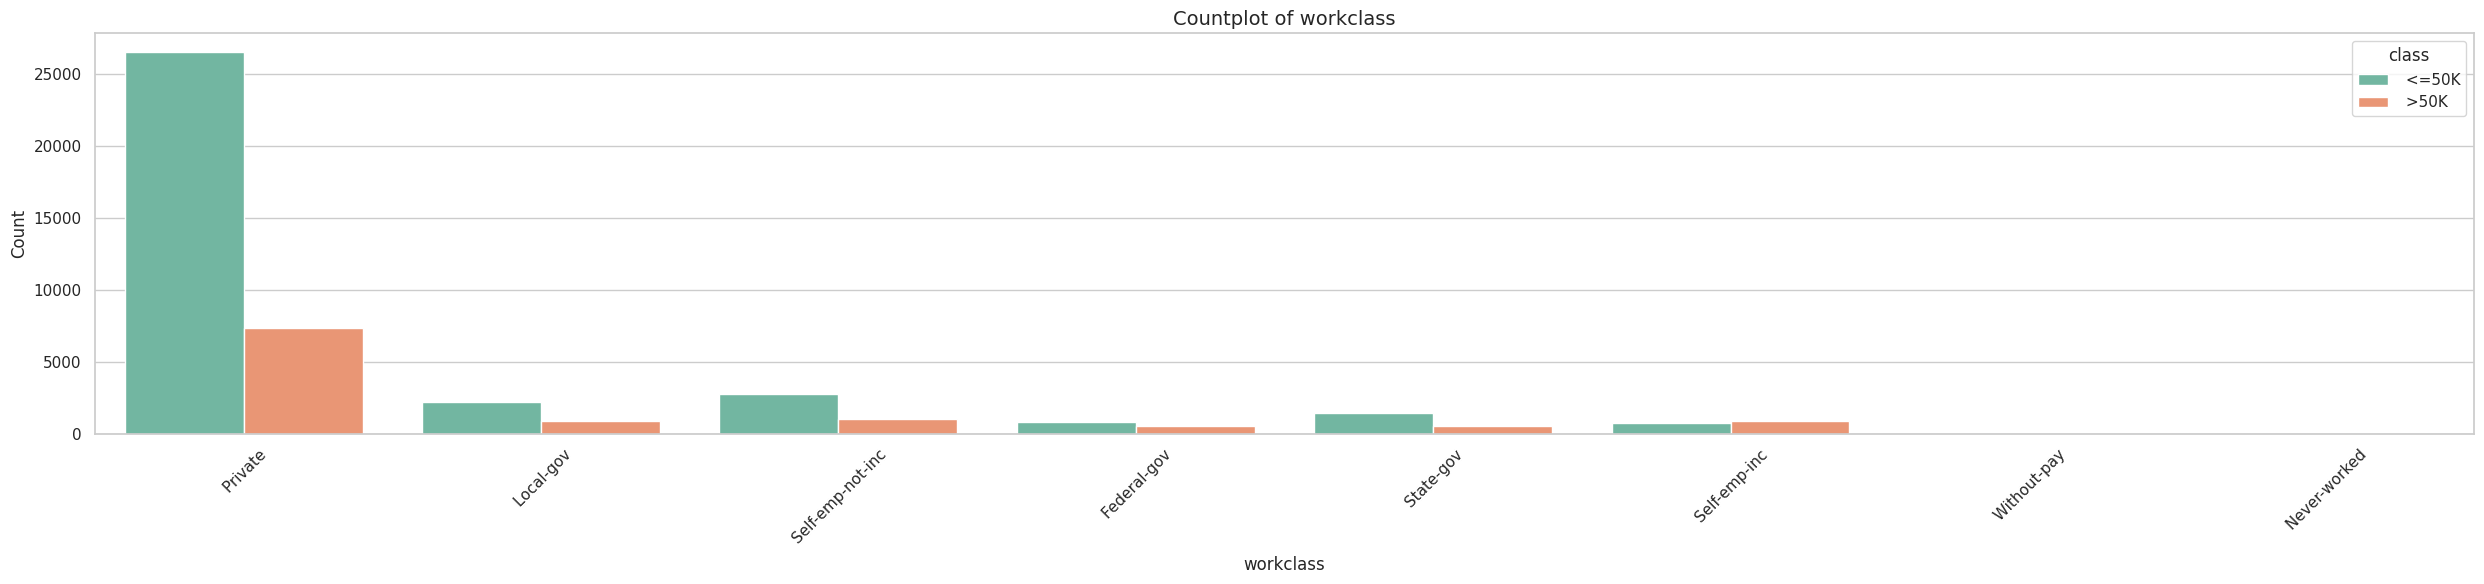

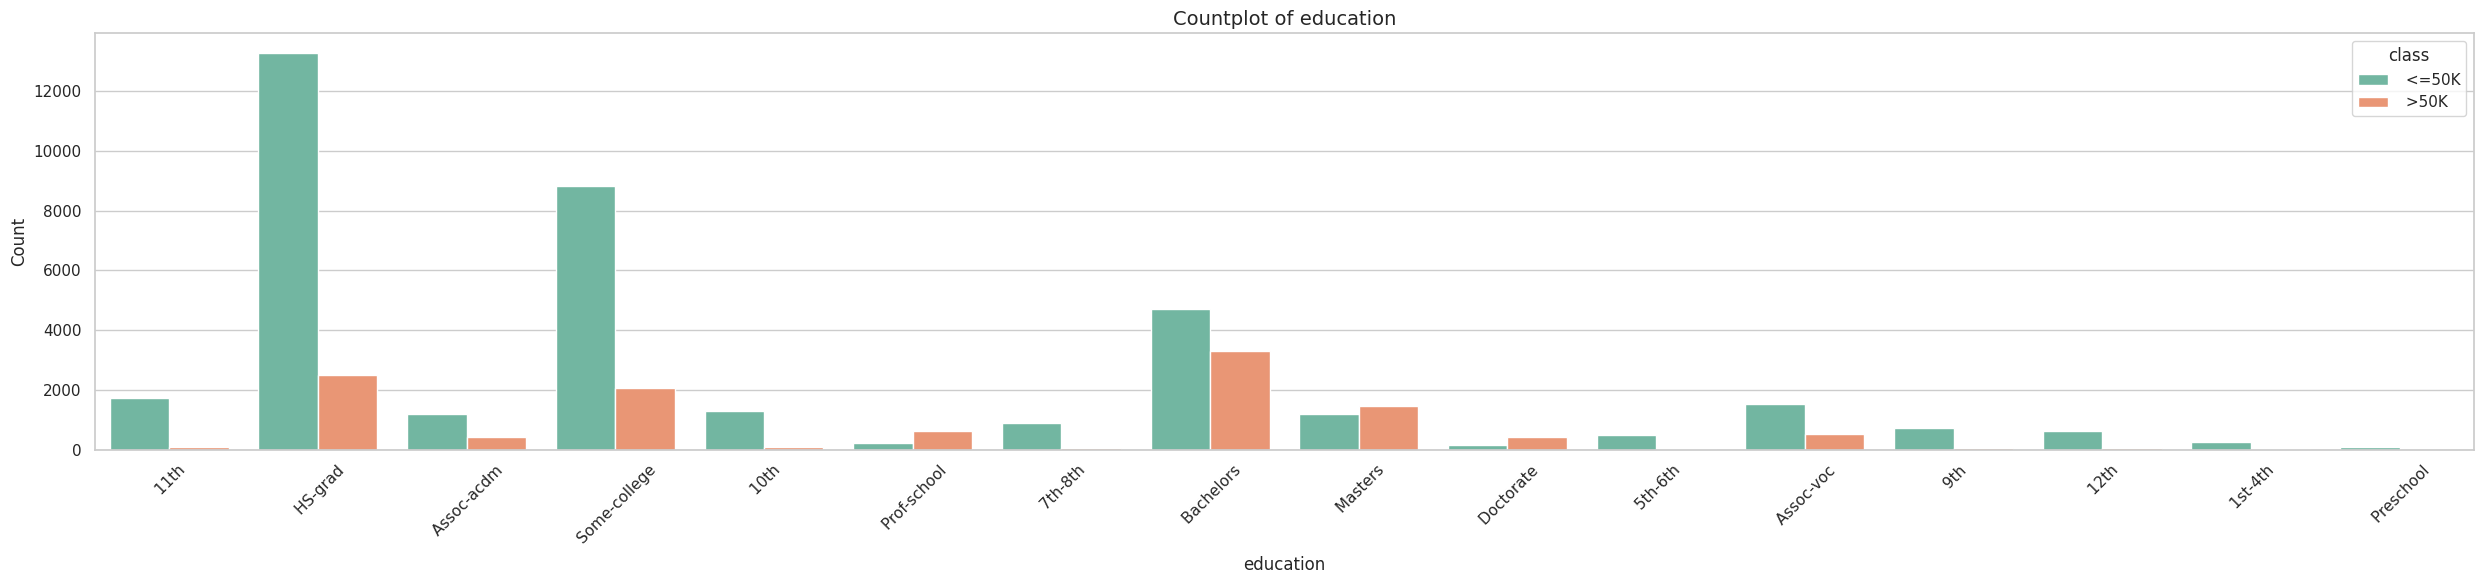

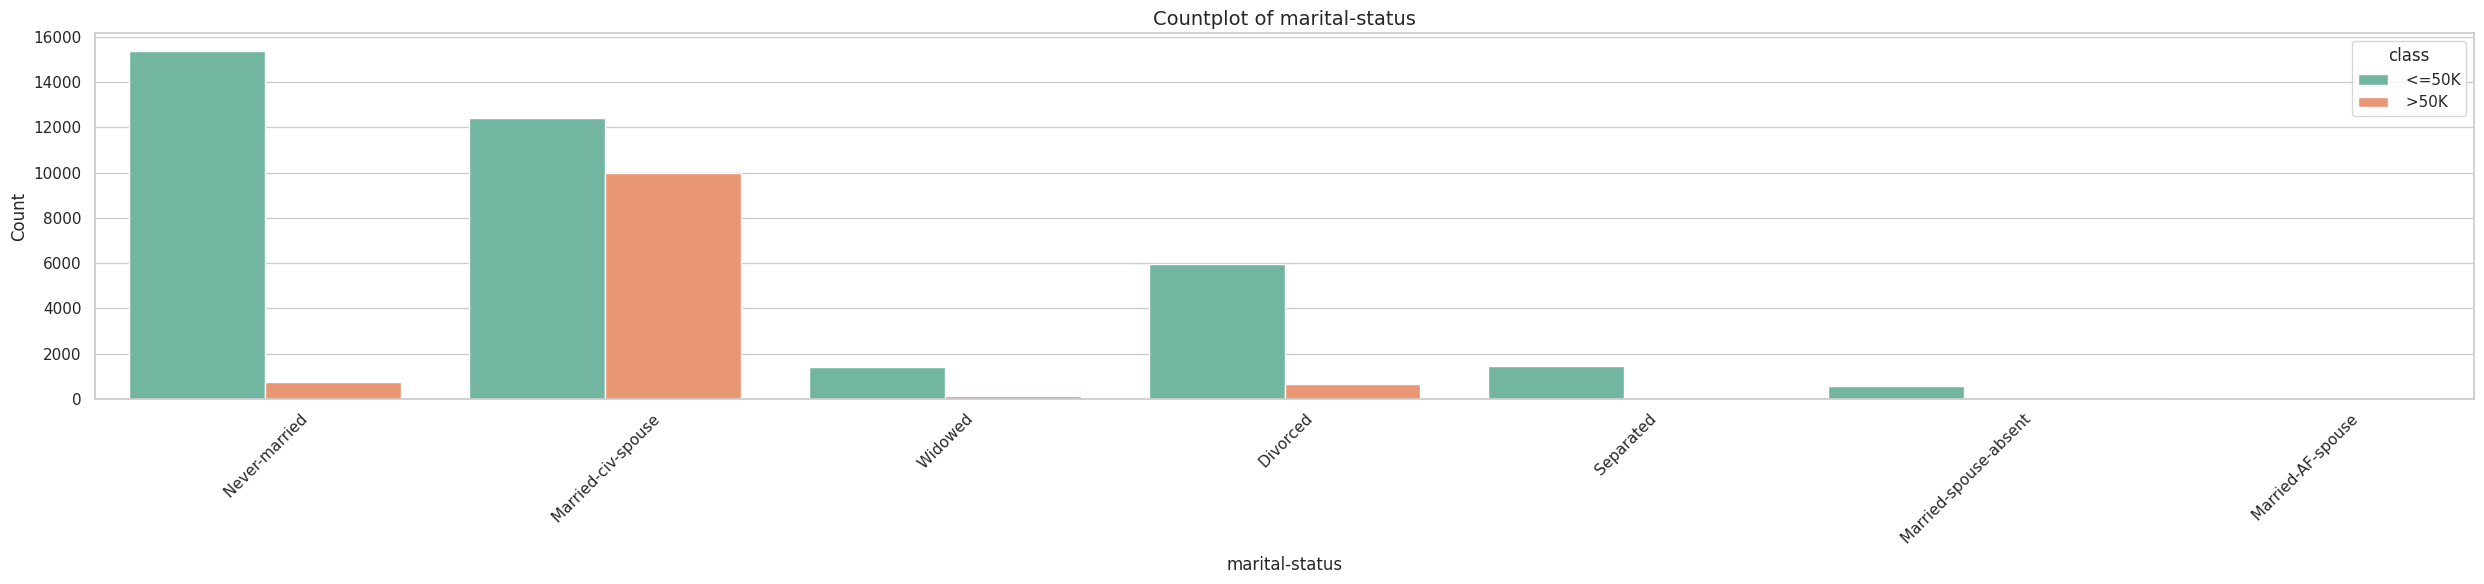

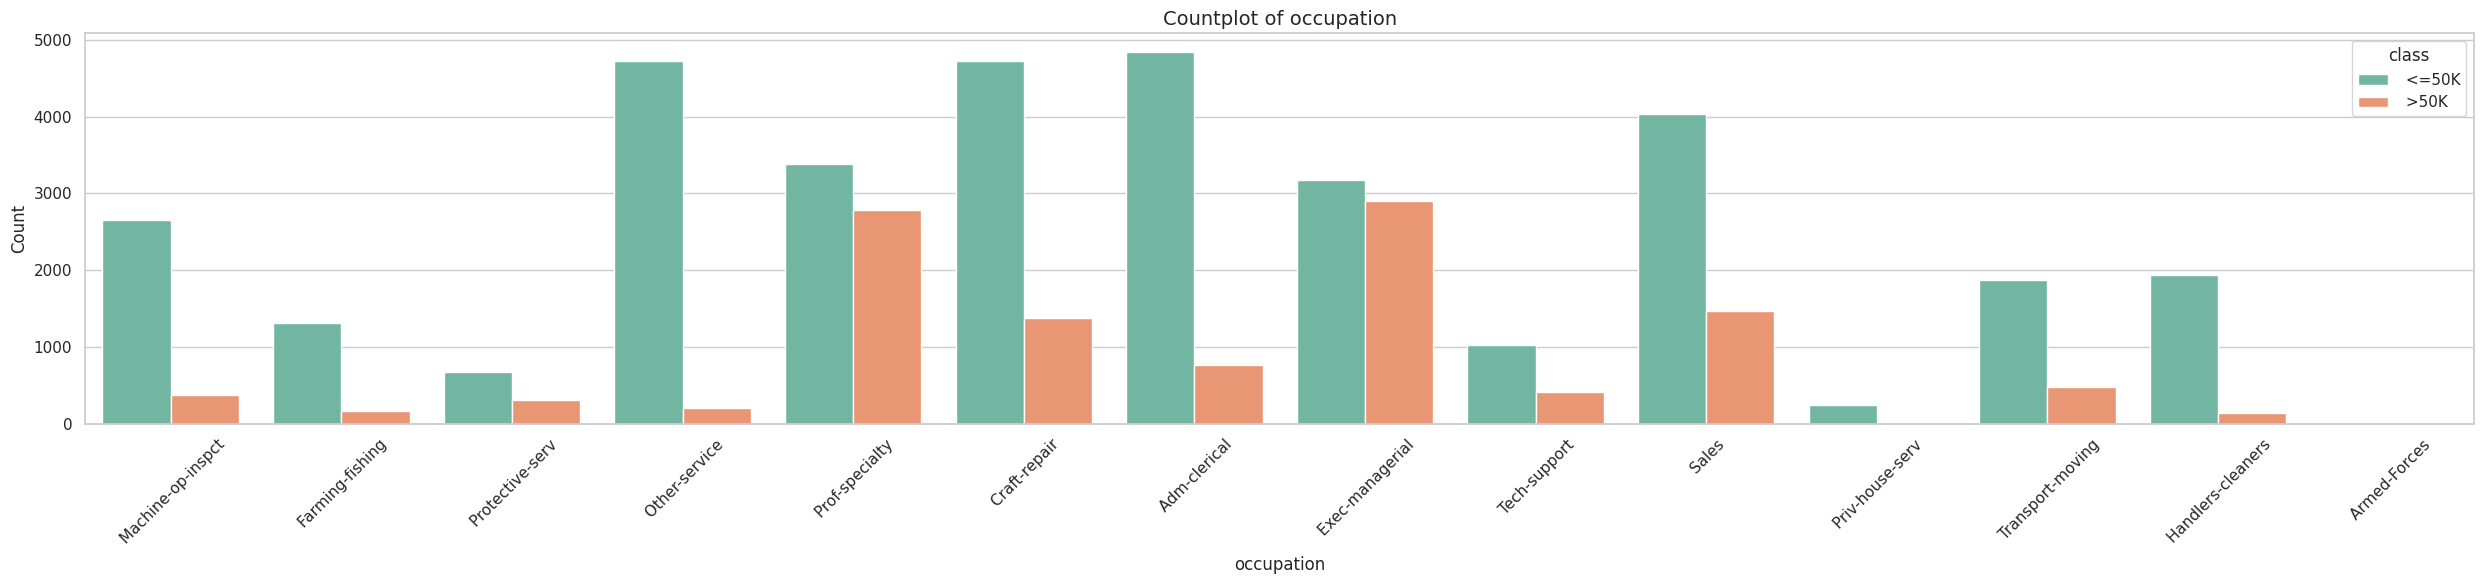

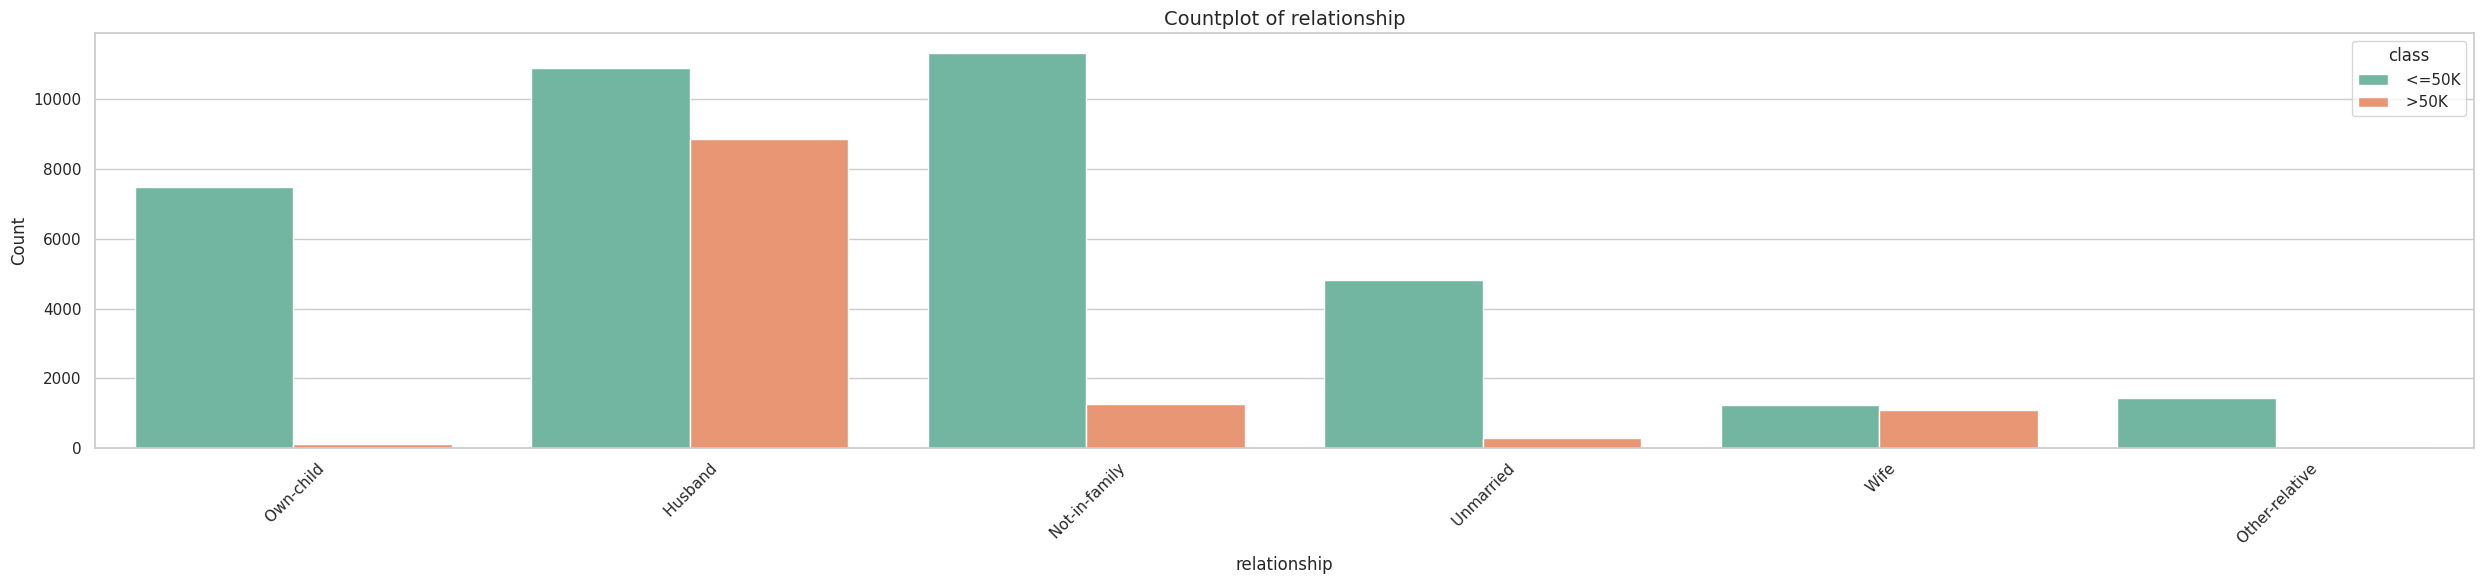

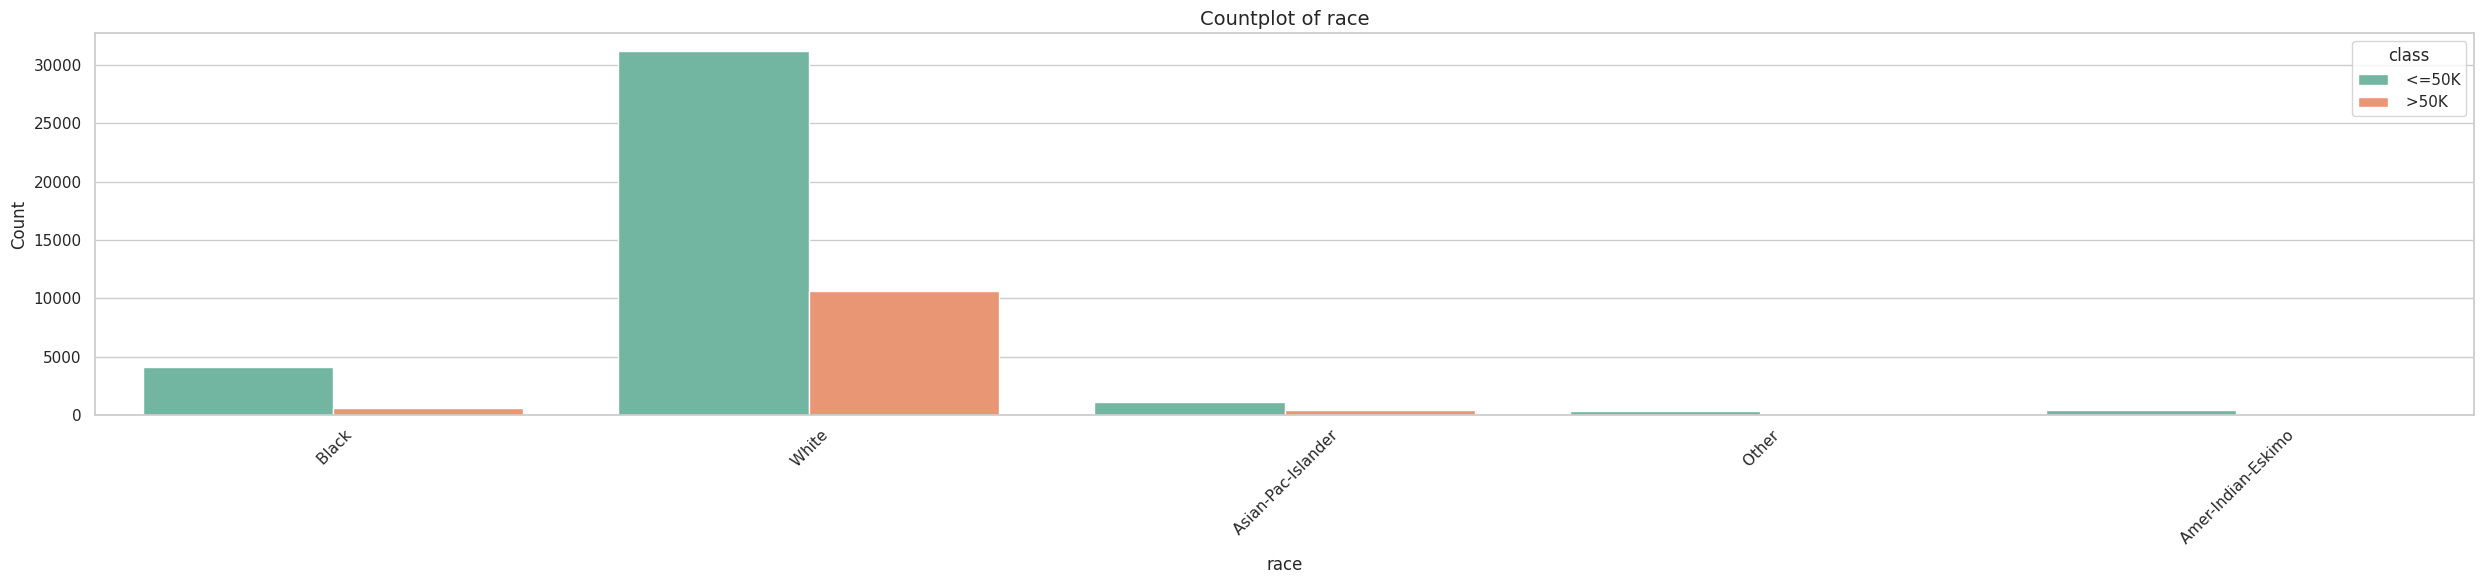

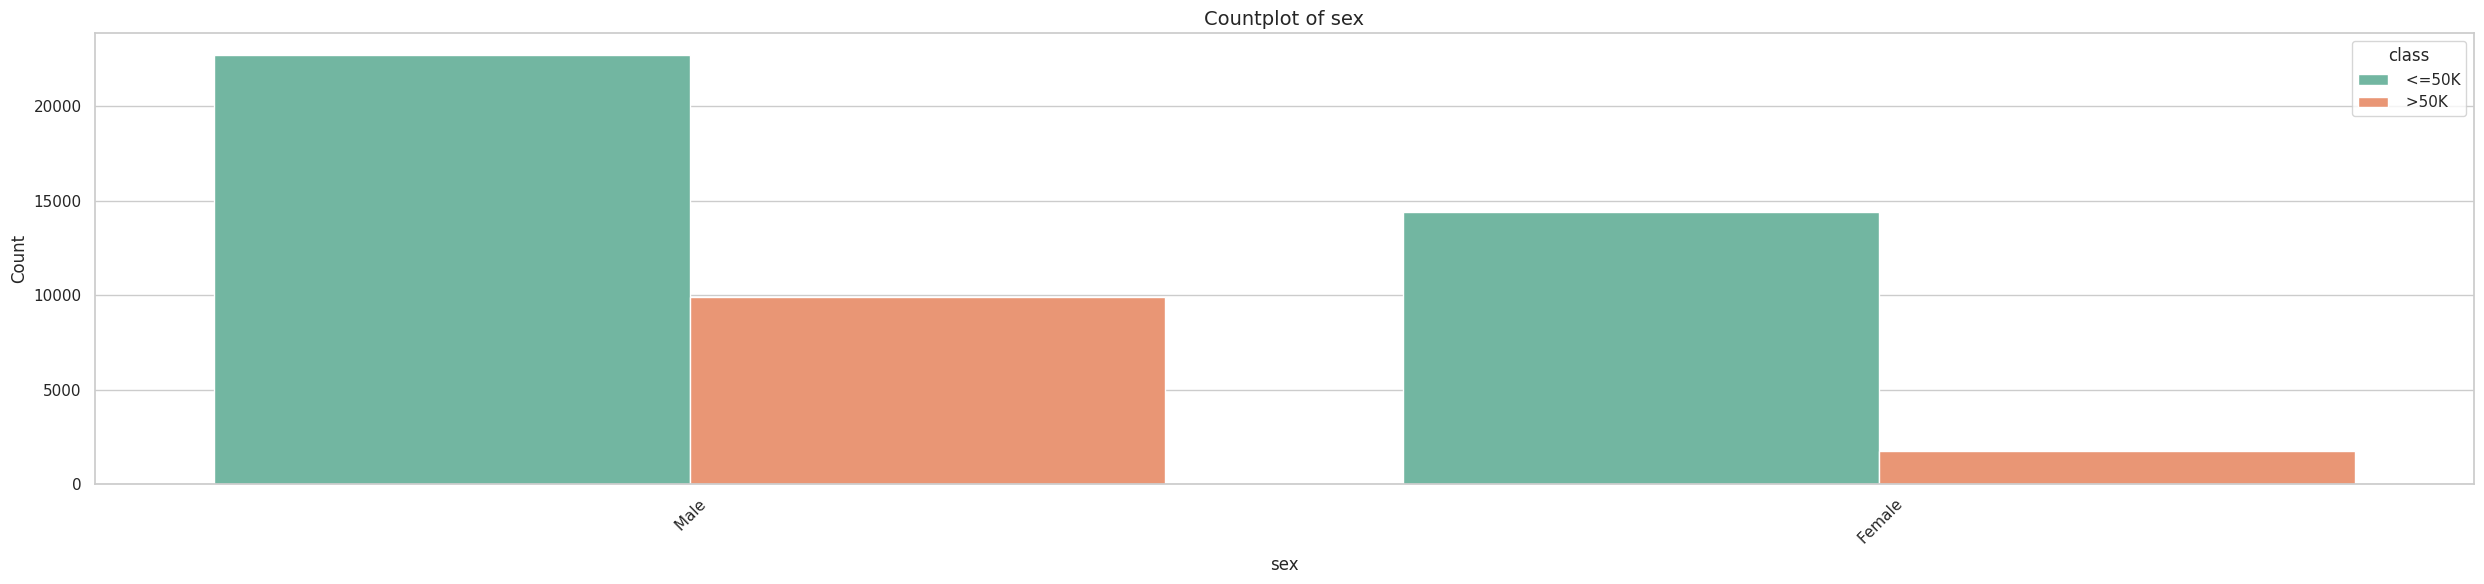

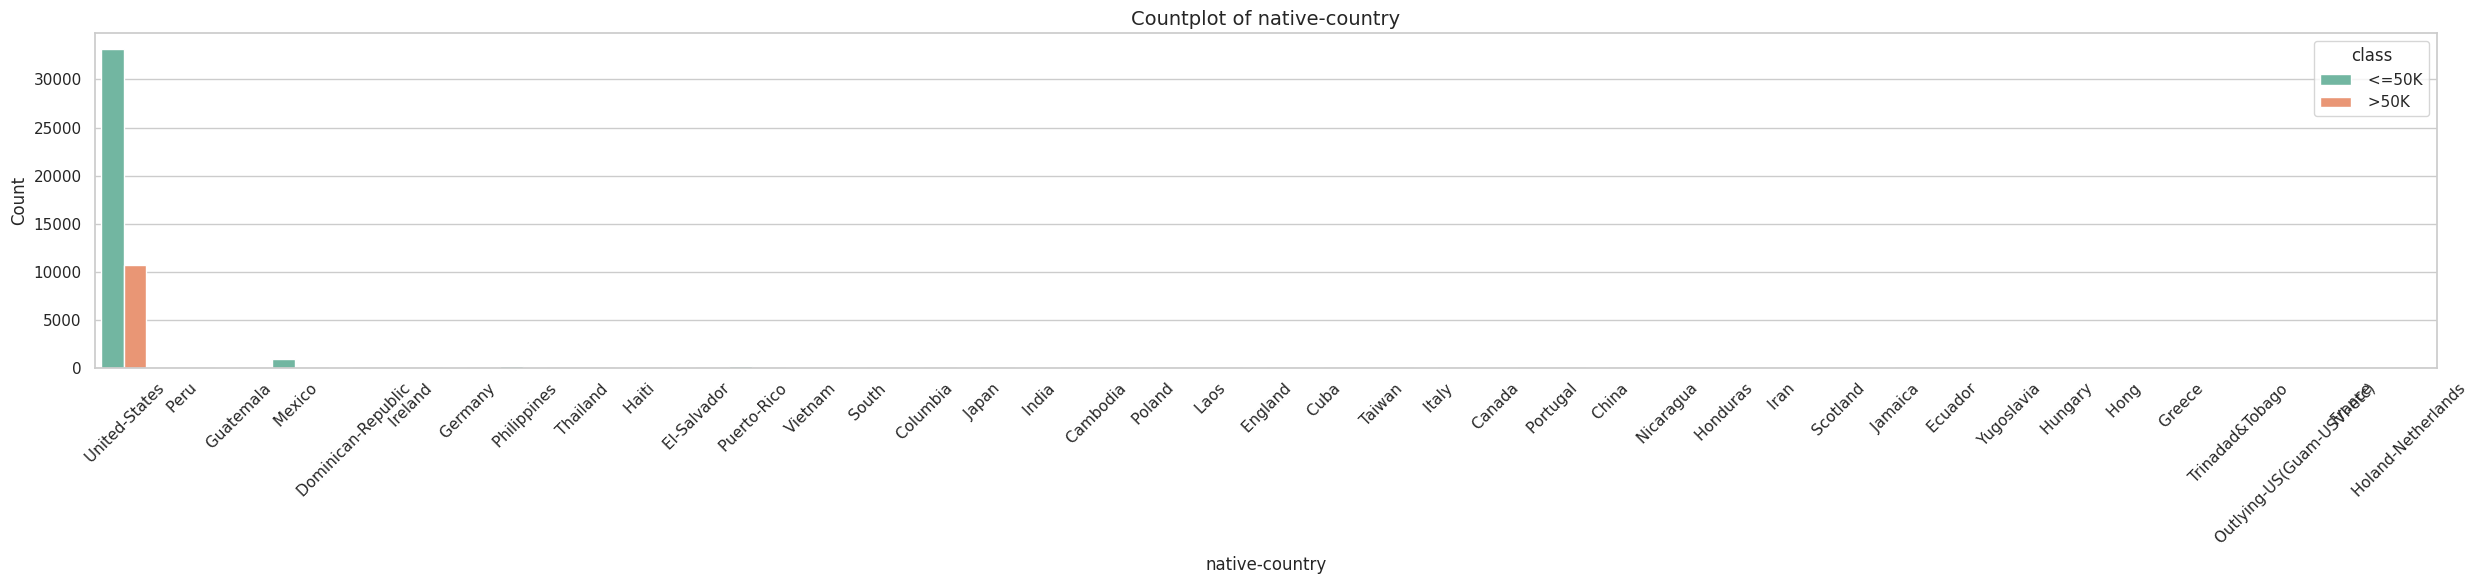

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Style Settings
sns.set_style("whitegrid")
sns.set_context("notebook")
sns.set_palette("Set2")

#--Your Plot Here--
for col in categorical_cols:
  plt.figure(figsize=(25,6))
  sns.countplot(
    data=df,
    x=col,
    hue="class",
    palette="Set2"
  )

  plt.title(f"Countplot of {col}",fontsize=14)
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

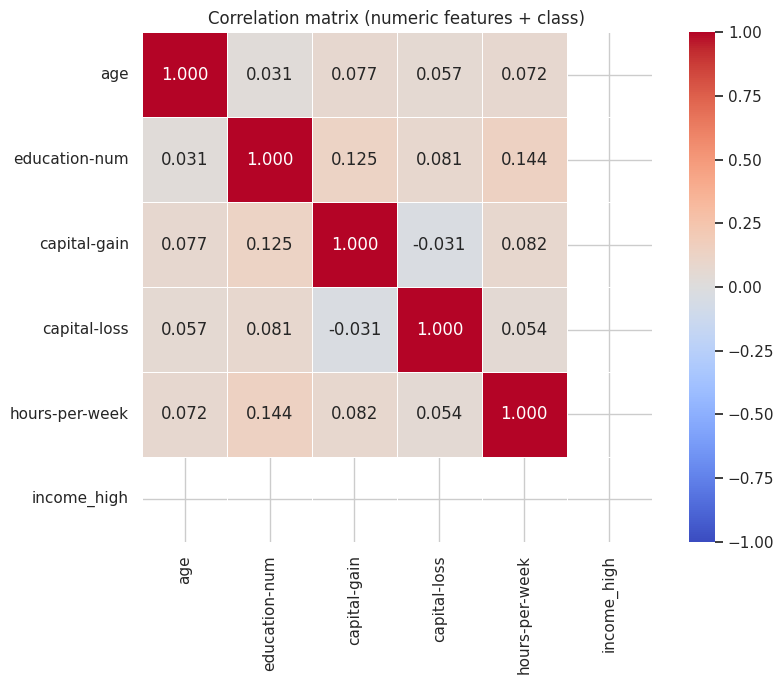

In [20]:
#heatmap based upon correlation coefficient

df_corr=df.copy()
df_corr['income_high']=(df_corr['class']=='>50k').astype(int)
corr=df_corr[list(numerical_cols)+['income_high']].corr().round(3)

plt.figure(figsize=(9,7))
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1,linewidths=0.5,fmt='.3f',square=True)
plt.title('Correlation matrix (numeric features + class)')
plt.tight_layout()
plt.show()

In [21]:
#Feature engineering and coefficient analysis

print(numerical_cols)
print(categorical_cols)

Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


In [22]:
#drop null values
print("before dropping nulls:",df.shape)
df.dropna(inplace=True)
print("after dropping nulls:",df.shape)

before dropping nulls: (48842, 14)
after dropping nulls: (45222, 14)


In [23]:
df['class'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [24]:
df['class']=df['class'].apply(lambda x:1 if x==' >50K' else 0)

In [25]:
df['class']

,class
0,0
1,0
2,1
3,1
5,0
...,...
48837,0
48838,1
48839,0
48840,0


In [26]:
df['class'].value_counts()

,count
class,
0,34014
1,11208


In [27]:
#encode categorical columns using one hot encoding
print(df.shape)
df_encoded=pd.get_dummies(df,columns=categorical_cols,drop_first=True)
print(df_encoded.shape)

(45222, 14)
(45222, 96)


In [28]:
df_encoded.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,class,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,1,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,1,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,6,0,0,30,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [29]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 96 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   age                                         45222 non-null  int64
 1   education-num                               45222 non-null  int64
 2   capital-gain                                45222 non-null  int64
 3   capital-loss                                45222 non-null  int64
 4   hours-per-week                              45222 non-null  int64
 5   class                                       45222 non-null  int64
 6   workclass_ Local-gov                        45222 non-null  bool 
 7   workclass_ Private                          45222 non-null  bool 
 8   workclass_ Self-emp-inc                     45222 non-null  bool 
 9   workclass_ Self-emp-not-inc                 45222 non-null  bool 
 10  workclass_ State-gov                   

In [30]:
bool_cols=df_encoded.select_dtypes(include=['bool']).columns
for col in bool_cols:
  df_encoded[col]=df_encoded[col].astype(int)

In [31]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 96 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   age                                         45222 non-null  int64
 1   education-num                               45222 non-null  int64
 2   capital-gain                                45222 non-null  int64
 3   capital-loss                                45222 non-null  int64
 4   hours-per-week                              45222 non-null  int64
 5   class                                       45222 non-null  int64
 6   workclass_ Local-gov                        45222 non-null  int64
 7   workclass_ Private                          45222 non-null  int64
 8   workclass_ Self-emp-inc                     45222 non-null  int64
 9   workclass_ Self-emp-not-inc                 45222 non-null  int64
 10  workclass_ State-gov                   

In [32]:
#print columns of df_encoded which are not integer or float
non_numeric_cols = df_encoded.select_dtypes(exclude=['int64','float64']).columns
print("Non-numeric columns:",non_numeric_cols)

Non-numeric columns: Index([], dtype='object')


In [33]:
df_encoded.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,class,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,38,9,0,0,50,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,28,12,0,0,40,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,44,10,7688,0,40,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
5,34,6,0,0,30,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [34]:
#split the df_encoded into train and test - stratified sampling based on income distribution
x=df_encoded.drop(columns=['class'])
y=df_encoded['class']

In [35]:
# Select only 5 important features
x = df[['age',
        'education-num',
        'hours-per-week',
        'capital-gain',
        'capital-loss']]

y = df['class']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
#check stratification by looking at class distribution in train and test
print("Train Class Distribution:\n",y_train.value_counts(normalize=True))
print("Test Class Distribution:\n",y_test.value_counts(normalize=True))

Train Class Distribution:
 class
0    0.752163
1    0.247837
Name: proportion, dtype: float64
Test Class Distribution:
 class
0    0.752128
1    0.247872
Name: proportion, dtype: float64


In [37]:
#Training the model
x_train.columns

Index(['age', 'education-num', 'hours-per-week', 'capital-gain',
       'capital-loss'],
      dtype='object')

In [38]:
#simple logistic regression model train using education-num numerical column
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train[['education-num']],y_train)

#prediction on the test dataset
y_pred=model.predict(x_test[['education-num']])

In [39]:
#check for classification and regression metrics
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve

In [40]:
#confusion matrix
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

cr=classification_report(y_test,y_pred)
print("Classification Report:\n",cr)

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

precision=precision_score(y_test,y_pred)
print("Precision:",precision)

recall=recall_score(y_test,y_pred)
print("Recall:",recall)

f1=f1_score(y_test,y_pred)
print("F1 Score:",f1)

roc_auc_score=roc_auc_score(y_test,y_pred)
print("ROC AUC Score:",roc_auc_score)

precision_vals,recall_vals,_=precision_recall_curve(y_test,y_pred)
print("Precision-Recall Curve:\n",list(zip(precision_vals,recall_vals)))

fpr,tpr,_=roc_curve(y_test,y_pred)
print("ROC Curve:\n",list(zip(fpr,tpr)))

recall=recall_score(y_test,y_pred)
print("Recall:",recall)

Confusion Matrix:
 [[6524  279]
 [1797  445]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.96      0.86      6803
           1       0.61      0.20      0.30      2242

    accuracy                           0.77      9045
   macro avg       0.70      0.58      0.58      9045
weighted avg       0.74      0.77      0.72      9045

Accuracy: 0.7704809286898839
Precision: 0.6146408839779005
Recall: 0.19848349687778769
F1 Score: 0.3000674308833446
ROC AUC Score: 0.5787360891709239
Precision-Recall Curve:
 [(np.float64(0.2478717523493643), np.float64(1.0)), (np.float64(0.6146408839779005), np.float64(0.19848349687778769)), (np.float64(1.0), np.float64(0.0))]
ROC Curve:
 [(np.float64(0.0), np.float64(0.0)), (np.float64(0.041011318535940026), np.float64(0.19848349687778769)), (np.float64(1.0), np.float64(1.0))]
Recall: 0.19848349687778769


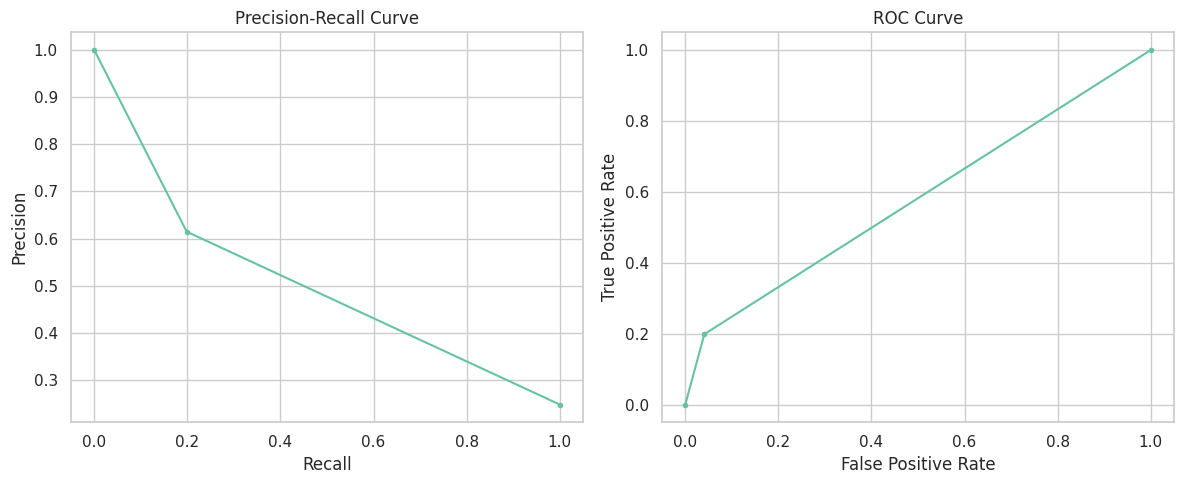

In [41]:
#plot the precision recall curve and roc curve using seaborn and matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

#Precision-Recall Curve
plt.subplot(1,2,1)
plt.plot(recall_vals,precision_vals,marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

#ROC Curve
plt.subplot(1,2,2)
plt.plot(fpr,tpr,marker='.')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.tight_layout()
plt.show()

In [42]:
#train a multiple logistic regression model using all the features and check the performance
from sklearn.linear_model import LogisticRegression

model_multi=LogisticRegression(max_iter=1000,class_weight='balanced')
model_multi.fit(x_train,y_train)
y_pred_multi=model_multi.predict(x_test)

from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve
#evaluation metrics for multiple logistic regression model
cm_multi=confusion_matrix(y_test,y_pred_multi)
print("Confusion Matrix:\n",cm_multi)

cr_multi=classification_report(y_test,y_pred_multi)
print("Classification Report:\n",cr_multi)

accuracy_multi=accuracy_score(y_test,y_pred_multi)
print("Accuracy:",accuracy_multi)

precision_multi=precision_score(y_test,y_pred_multi)
print("Precision:",precision_multi)

recall_multi=recall_score(y_test,y_pred_multi)
print("Recall:",recall_multi)

f1_multi=f1_score(y_test,y_pred_multi)
print("F1 Score:",f1_multi)

roc_auc_multi=roc_auc_score(y_test,y_pred_multi)
print("ROC AUC Score:",roc_auc_multi)

precision_vals_multi,recall_vals_multi,_=precision_recall_curve(y_test,y_pred_multi)
print("Precision-Recall Curve:\n",list(zip(precision_vals_multi,recall_vals_multi)))

fpr_multi,tpr_multi,_=roc_curve(y_test,y_pred_multi)
print("ROC Curve:\n",list(zip(fpr_multi,tpr_multi)))

fpr,tpr,_=roc_curve(y_test,y_pred)
print("ROC Curve:\n",list(zip(fpr,tpr)))

recall=recall_score(y_test,y_pred)
print("Recall:",recall)

Confusion Matrix:
 [[5249 1554]
 [ 655 1587]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.83      6803
           1       0.51      0.71      0.59      2242

    accuracy                           0.76      9045
   macro avg       0.70      0.74      0.71      9045
weighted avg       0.79      0.76      0.77      9045

Accuracy: 0.7557766721945827
Precision: 0.5052531041069723
Recall: 0.707850133809099
F1 Score: 0.589634033067063
ROC AUC Score: 0.7397107496915554
Precision-Recall Curve:
 [(np.float64(0.2478717523493643), np.float64(1.0)), (np.float64(0.5052531041069723), np.float64(0.707850133809099)), (np.float64(1.0), np.float64(0.0))]
ROC Curve:
 [(np.float64(0.0), np.float64(0.0)), (np.float64(0.22842863442598854), np.float64(0.707850133809099)), (np.float64(1.0), np.float64(1.0))]
ROC Curve:
 [(np.float64(0.0), np.float64(0.0)), (np.float64(0.041011318535940026), np.float64(0.19848349687778769)), (np.float

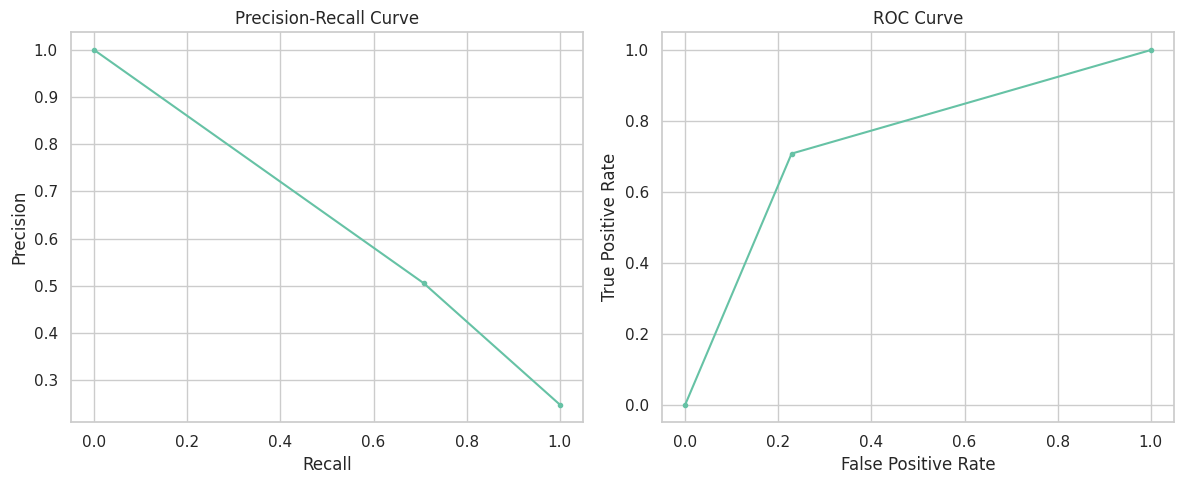

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(recall_vals_multi,precision_vals_multi,marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.subplot(1,2,2)
plt.plot(fpr_multi,tpr_multi,marker='.')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.tight_layout()
plt.show()

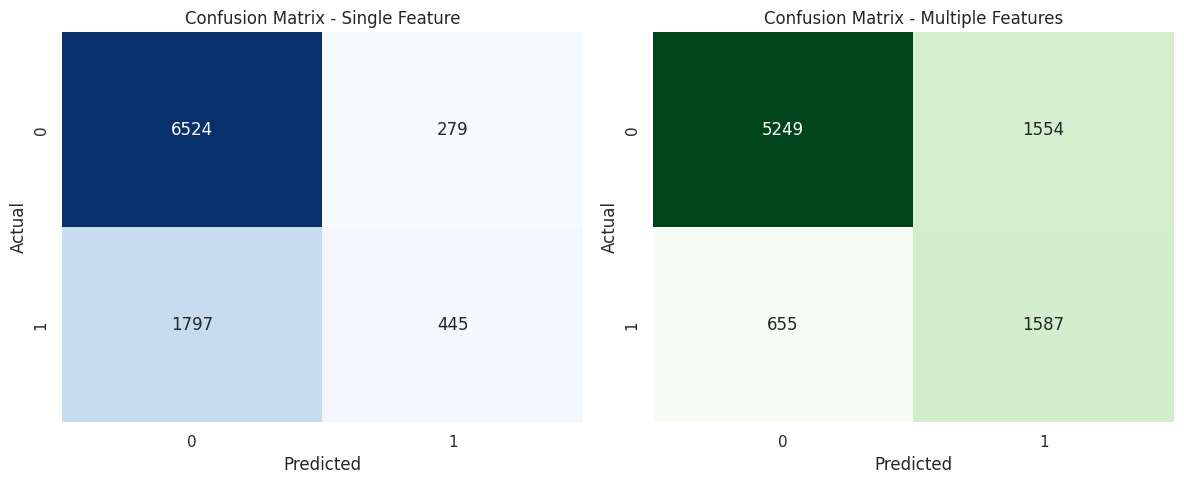

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False)
plt.title('Confusion Matrix - Single Feature')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(1,2,2)
sns.heatmap(cm_multi,annot=True,fmt='d',cmap='Greens',cbar=False)
plt.title('Confusion Matrix - Multiple Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [45]:
#analysis of the coefficients of multiple logistic regression model
coefficients=pd.DataFrame({
    'Feature':x_train.columns,
    'Coefficient':model_multi.coef_[0]
}).sort_values(by='Coefficient',key=abs,ascending=False)
print(coefficients)

          Feature  Coefficient
1   education-num     0.321612
0             age     0.048768
2  hours-per-week     0.045504
4    capital-loss     0.000686
3    capital-gain     0.000311


In [46]:
#print top 10 features
coefficients.head(10)

,Feature,Coefficient
1,education-num,0.321612
0,age,0.048768
2,hours-per-week,0.045504
4,capital-loss,0.000686
3,capital-gain,0.000311


In [47]:
#print least 10 important features
coefficients.tail(10)

,Feature,Coefficient
1,education-num,0.321612
0,age,0.048768
2,hours-per-week,0.045504
4,capital-loss,0.000686
3,capital-gain,0.000311


In [48]:
import pickle
with open('model.pkl','wb') as file:
  pickle.dump(model_multi, file)

In [49]:
import sklearn
print("numpy",np.__version__)
print("pandas",pd.__version__)
print("seaborn",sns.__version__)
print("sklearn",sklearn.__version__)

numpy 2.0.2
pandas 2.2.2
seaborn 0.13.2
sklearn 1.6.1
